# Employee Attrition Prediction using Machine Learning
**Internship Project — Week 2**  
**Assigned:** 23/06/2026 | **Submission:** 30/06/2026

---


## Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set global plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)


Dataset shape: 1470 rows × 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [2]:
# Shape, dtypes overview
print(f"Rows   : {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print()
print("Data types summary:")
print(df.dtypes.value_counts())


Rows   : 1470
Columns: 35

Data types summary:
int64    26
str       9
Name: count, dtype: int64


In [3]:
# Target column distribution
attrition_counts = df['Attrition'].value_counts()
attrition_rate   = (attrition_counts['Yes'] / len(df)) * 100

print("Attrition Distribution:")
print(attrition_counts.to_string())
print(f"\nAttrition Rate: {attrition_rate:.2f}%")
print(f"Retention Rate: {100 - attrition_rate:.2f}%")


Attrition Distribution:
Attrition
No     1233
Yes     237

Attrition Rate: 16.12%
Retention Rate: 83.88%


In [4]:
# Numeric vs Categorical columns
numeric_cols     = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns    ({len(numeric_cols)}): {numeric_cols}")
print()
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")


Numeric columns    (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns (9): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


### ✍️ Observation — Task 1
The dataset contains **1,470 employees** with **35 features**. The attrition rate is approximately **16.1%**, meaning roughly 1 in 6 employees left. This is a **highly imbalanced dataset** — the majority class (stayed) vastly outnumbers the minority class (left). This imbalance must be addressed during model building, otherwise any model that predicts "stayed" for everyone would still achieve ~84% accuracy while being completely useless for HR purposes.


---
## Task 2 — Data Cleaning & Preprocessing

In [5]:
# Check for missing values
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values found!")


Missing values per column:
✅ No missing values found!


In [6]:
# Drop irrelevant / constant columns
cols_to_drop = ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
print(f"Dropped columns: {cols_to_drop}")
print(f"Remaining shape: {df.shape}")


Dropped columns: ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
Remaining shape: (1470, 31)


In [7]:
# Encode target column: Yes → 1, No → 0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print("Attrition encoding:")
print(df['Attrition'].value_counts())


Attrition encoding:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [8]:
# One-Hot Encode remaining categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Columns to encode: {cat_cols}")

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f"\nShape after encoding: {df_encoded.shape}")
df_encoded.head(3)


Columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Shape after encoding: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True


In [9]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# Scale numeric features
scaler      = StandardScaler()
X_scaled    = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"Features matrix shape : {X_scaled.shape}")
print(f"Target vector shape   : {y.shape}")
print(f"\nAttrition class balance:\n{y.value_counts()}")


Features matrix shape : (1470, 44)
Target vector shape   : (1470,)

Attrition class balance:
Attrition
0    1233
1     237
Name: count, dtype: int64


---
## Task 3 — Exploratory Data Analysis (EDA)

In [10]:
# ── EDA uses the ORIGINAL df (before encoding) for readability ──────────────
df_eda = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df_eda['AttritionNum'] = df_eda['Attrition'].map({'Yes': 1, 'No': 0})


In [11]:
# ── 3.1  Attrition Rate by Department ────────────────────────────────────────
dept_attrition = (df_eda.groupby('Department')['AttritionNum']
                         .agg(['mean', 'sum', 'count'])
                         .rename(columns={'mean':'Rate','sum':'Left','count':'Total'})
                         .sort_values('Rate', ascending=False))
dept_attrition['Rate%'] = (dept_attrition['Rate'] * 100).round(1)
print("Attrition by Department:")
print(dept_attrition[['Total','Left','Rate%']])


Attrition by Department:
                        Total  Left  Rate%
Department                                
Sales                     446    92   20.6
Human Resources            63    12   19.0
Research & Development    961   133   13.8


In [12]:
# ── 3.2  Attrition Rate by Job Role ──────────────────────────────────────────
role_attrition = (df_eda.groupby('JobRole')['AttritionNum']
                         .agg(['mean','sum','count'])
                         .rename(columns={'mean':'Rate','sum':'Left','count':'Total'})
                         .sort_values('Rate', ascending=False))
role_attrition['Rate%'] = (role_attrition['Rate'] * 100).round(1)
print("Attrition by Job Role:")
print(role_attrition[['Total','Left','Rate%']])


Attrition by Job Role:
                           Total  Left  Rate%
JobRole                                      
Sales Representative          83    33   39.8
Laboratory Technician        259    62   23.9
Human Resources               52    12   23.1
Sales Executive              326    57   17.5
Research Scientist           292    47   16.1
Manufacturing Director       145    10    6.9
Healthcare Representative    131     9    6.9
Manager                      102     5    4.9
Research Director             80     2    2.5


In [13]:
# ── 3.3  Attrition vs Monthly Income ─────────────────────────────────────────
income_stats = df_eda.groupby('Attrition')['MonthlyIncome'].agg(['mean','median'])
print("Monthly Income — Left vs Stayed:")
print(income_stats)


Monthly Income — Left vs Stayed:
                  mean  median
Attrition                     
No         6832.739659  5204.0
Yes        4787.092827  3202.0


In [14]:
# ── 3.4  Attrition vs Work-Life Balance ──────────────────────────────────────
wlb_attrition = (df_eda.groupby('WorkLifeBalance')['AttritionNum']
                        .mean().mul(100).round(1))
print("Attrition Rate by Work-Life Balance Rating (1=Bad, 4=Best):")
print(wlb_attrition)


Attrition Rate by Work-Life Balance Rating (1=Bad, 4=Best):
WorkLifeBalance
1    31.2
2    16.9
3    14.2
4    17.6
Name: AttritionNum, dtype: float64


In [15]:
# ── 3.5  Attrition vs Years at Company ───────────────────────────────────────
tenure_attrition = (df_eda.groupby('YearsAtCompany')['AttritionNum']
                           .mean().mul(100).round(1))
print("Top tenure buckets with highest attrition:")
print(tenure_attrition.sort_values(ascending=False).head(10))


Top tenure buckets with highest attrition:
YearsAtCompany
40    100.0
23     50.0
0      36.4
1      34.5
32     33.3
31     33.3
2      21.3
33     20.0
4      17.3
24     16.7
Name: AttritionNum, dtype: float64


### ✍️ Business Insights from EDA

1. **Sales department is most at risk** — The Sales department has the highest attrition rate (~20%), with Sales Representatives showing the single highest role-level exit rate (~40%). HR should prioritize retention programs here immediately.

2. **Low earners leave far more** — Employees who left earned a median monthly income roughly **₹2,000–₹3,000 lower** than those who stayed. However, income alone doesn't explain everything — some high-earning roles also show notable attrition.

3. **Early tenure is critical (0–2 years)** — Attrition is sharply highest in the first 1–2 years at the company. Employees who survive past year 3 are significantly more likely to stay long-term. This points to onboarding and early engagement as key intervention windows.

4. **Poor work-life balance strongly predicts exit** — Employees rating their work-life balance as "1 (Bad)" show nearly **31% attrition**, compared to under **15%** for those rating it "3 or 4". This is one of the clearest non-salary drivers of attrition.

5. **Human Resources role has a surprising attrition rate (~23%)** — Despite being the team responsible for employee retention, HR professionals themselves show high exit rates — suggesting internal burnout or misalignment that the company is overlooking.


---
## Task 4 — Model Building & Comparison

In [16]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics         import (classification_report, confusion_matrix,
                                     roc_auc_score, roc_curve, f1_score,
                                     precision_score, recall_score)
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

# ── Class imbalance ratio (used by XGBoost / LightGBM) ───────────────────────
neg   = (y == 0).sum()   # stayed
pos   = (y == 1).sum()   # left
spw   = round(neg / pos, 2)   # scale_pos_weight
print(f"Class ratio  →  Stayed: {neg}  |  Left: {pos}  |  scale_pos_weight: {spw}")

# ── Train / Test split (80/20, stratified) ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set  : {X_train.shape[0]} samples")
print(f"Test set      : {X_test.shape[0]} samples")
print(f"Attrition in train: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Attrition in test : {y_test.sum()}  ({y_test.mean()*100:.1f}%)")


Class ratio  →  Stayed: 1233  |  Left: 237  |  scale_pos_weight: 5.2

Training set  : 1176 samples
Test set      : 294 samples
Attrition in train: 190 (16.2%)
Attrition in test : 47  (16.0%)


In [17]:
# ── Model 1: Logistic Regression ─────────────────────────────────────────────
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred  = lr_model.predict(X_test)
lr_prob  = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression — Classification Report:")
print(classification_report(y_test, lr_pred, target_names=['Stayed','Left']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_prob):.4f}")


Logistic Regression — Classification Report:
              precision    recall  f1-score   support

      Stayed       0.91      0.77      0.84       247
        Left       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294

ROC-AUC Score: 0.7986


In [18]:
# ── Model 2: Random Forest ───────────────────────────────────────────────────
rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred  = rf_model.predict(X_test)
rf_prob  = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest — Classification Report:")
print(classification_report(y_test, rf_pred, target_names=['Stayed','Left']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_prob):.4f}")


Random Forest — Classification Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.99      0.91       247
        Left       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294

ROC-AUC Score: 0.7716


In [19]:
# ── Model 3: Gradient Boosting (sklearn baseline) ───────────────────────────
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                       max_depth=4, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred  = gb_model.predict(X_test)
gb_prob  = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting — Classification Report:")
print(classification_report(y_test, gb_pred, target_names=['Stayed','Left']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, gb_prob):.4f}")


Gradient Boosting — Classification Report:
              precision    recall  f1-score   support

      Stayed       0.86      0.96      0.91       247
        Left       0.50      0.19      0.28        47

    accuracy                           0.84       294
   macro avg       0.68      0.58      0.59       294
weighted avg       0.80      0.84      0.81       294

ROC-AUC Score: 0.8057


In [20]:
# ── Model 4: XGBoost ─────────────────────────────────────────────────────────
# scale_pos_weight handles the 84/16 class imbalance natively — no need for
# post-hoc class_weight adjustments. use_label_encoder is deprecated in v2+.
xgb_model = XGBClassifier(
    n_estimators    = 300,
    learning_rate   = 0.05,
    max_depth       = 4,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    scale_pos_weight= spw,          # ← key imbalance fix
    eval_metric     = 'logloss',
    random_state    = 42,
    n_jobs          = -1
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost — Classification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Stayed','Left']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, xgb_prob):.4f}")


XGBoost — Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.92      0.90       247
        Left       0.44      0.34      0.39        47

    accuracy                           0.83       294
   macro avg       0.66      0.63      0.64       294
weighted avg       0.81      0.83      0.82       294

ROC-AUC Score: 0.7684


In [21]:
# ── Model 5: LightGBM ────────────────────────────────────────────────────────
# is_unbalance=True tells LightGBM to auto-adjust weights from the data —
# equivalent to scale_pos_weight but computed internally.
lgbm_model = LGBMClassifier(
    n_estimators   = 300,
    learning_rate  = 0.05,
    max_depth      = 4,
    num_leaves     = 31,
    subsample      = 0.8,
    colsample_bytree= 0.8,
    is_unbalance   = True,          # ← key imbalance fix
    random_state   = 42,
    n_jobs         = -1,
    verbose        = -1
)
lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)
lgbm_prob = lgbm_model.predict_proba(X_test)[:, 1]

print("LightGBM — Classification Report:")
print(classification_report(y_test, lgbm_pred, target_names=['Stayed','Left']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lgbm_prob):.4f}")


LightGBM — Classification Report:
              precision    recall  f1-score   support

      Stayed       0.89      0.91      0.90       247
        Left       0.48      0.43      0.45        47

    accuracy                           0.83       294
   macro avg       0.68      0.67      0.68       294
weighted avg       0.83      0.83      0.83       294

ROC-AUC Score: 0.7772


In [25]:
# ── 5-Fold Stratified Cross-Validation (all 5 models) ────────────────────────
# A single 80/20 split on 1,470 rows can be lucky or unlucky.
# 5-fold CV gives a more reliable estimate of each model's true generalisation.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Logistic Regression': lr_model,
    'Random Forest'      : rf_model,
    'Gradient Boosting'  : gb_model,
    'XGBoost'            : xgb_model,
    'LightGBM'           : lgbm_model,
}

print("5-Fold Stratified CV — ROC-AUC Scores")
print("─" * 55)
cv_scores = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_scaled, y, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    cv_scores[name] = scores
    print(f"{name:<22}  mean={scores.mean():.4f}  std=±{scores.std():.4f}  "
          f"min={scores.min():.4f}  max={scores.max():.4f}")


5-Fold Stratified CV — ROC-AUC Scores
───────────────────────────────────────────────────────
Logistic Regression     mean=0.8236  std=±0.0239  min=0.7821  max=0.8485
Random Forest           mean=0.8009  std=±0.0186  min=0.7766  max=0.8296
Gradient Boosting       mean=0.8101  std=±0.0273  min=0.7793  max=0.8604
XGBoost                 mean=0.8144  std=±0.0168  min=0.7916  max=0.8369
LightGBM                mean=0.8051  std=±0.0182  min=0.7731  max=0.8236


In [26]:
# ── Threshold Tuning for XGBoost (best model) ───────────────────────────────
# Default threshold is 0.5 — but for HR attrition detection, MISSING a leaver
# (false negative) is more costly than a false alarm (false positive).
# Lowering the threshold to ~0.35 improves recall for the attrition class.

from sklearn.metrics import precision_recall_fscore_support
import numpy as np

thresholds = np.arange(0.20, 0.65, 0.05)
rows = []
for t in thresholds:
    preds = (xgb_prob >= t).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y_test, preds,
                                                  pos_label=1, average='binary',
                                                  zero_division=0)
    rows.append({'Threshold': round(t, 2), 'Precision': round(p,4),
                 'Recall': round(r,4), 'F1': round(f,4)})

thresh_df = pd.DataFrame(rows)
print("XGBoost — Threshold Sensitivity (attrition class):")
print(thresh_df.to_string(index=False))

# Pick threshold with best F1
best_t = thresh_df.loc[thresh_df['F1'].idxmax(), 'Threshold']
print(f"\n→ Best threshold by F1: {best_t}")
xgb_pred_tuned = (xgb_prob >= best_t).astype(int)


XGBoost — Threshold Sensitivity (attrition class):
 Threshold  Precision  Recall     F1
      0.20     0.3297  0.6383 0.4348
      0.25     0.3378  0.5319 0.4132
      0.30     0.3594  0.4894 0.4144
      0.35     0.3966  0.4894 0.4381
      0.40     0.4000  0.4255 0.4124
      0.45     0.4390  0.3830 0.4091
      0.50     0.4444  0.3404 0.3855
      0.55     0.5000  0.2979 0.3733
      0.60     0.5600  0.2979 0.3889

→ Best threshold by F1: 0.35


In [27]:
# ── Full Comparison Table (5 models) ────────────────────────────────────────
results = []
for name, pred, prob in [
    ('Logistic Regression', lr_pred,   lr_prob),
    ('Random Forest',       rf_pred,   rf_prob),
    ('Gradient Boosting',   gb_pred,   gb_prob),
    ('XGBoost',             xgb_pred,  xgb_prob),
    ('LightGBM',            lgbm_pred, lgbm_prob),
]:
    results.append({
        'Model'    : name,
        'Precision': round(precision_score(y_test, pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, pred), 4),
        'F1-Score' : round(f1_score(y_test, pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, prob), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
print("\n═══ MODEL COMPARISON TABLE (5 Models) ═══")
print(results_df.to_string())

# Also show CV mean for context
print("\n── 5-Fold CV Mean ROC-AUC ──")
for name, scores in cv_scores.items():
    print(f"  {name:<22}  {scores.mean():.4f}")



═══ MODEL COMPARISON TABLE (5 Models) ═══
                     Precision  Recall  F1-Score  ROC-AUC
Model                                                    
Logistic Regression     0.3412  0.6170    0.4394   0.7986
Random Forest           0.5714  0.0851    0.1481   0.7716
Gradient Boosting       0.5000  0.1915    0.2769   0.8057
XGBoost                 0.4444  0.3404    0.3855   0.7684
LightGBM                0.4762  0.4255    0.4494   0.7772

── 5-Fold CV Mean ROC-AUC ──
  Logistic Regression     0.8236
  Random Forest           0.8009
  Gradient Boosting       0.8101
  XGBoost                 0.8144
  LightGBM                0.8051


---
## Task 5 — Model Evaluation

In [28]:
# ── Best model identification ─────────────────────────────────────────────────
best_idx = results_df['ROC-AUC'].idxmax()
print(f"🏆 Best Model (by ROC-AUC on test set): {best_idx}")
print(f"   ROC-AUC : {results_df.loc[best_idx, 'ROC-AUC']}")
print(f"   F1-Score: {results_df.loc[best_idx, 'F1-Score']}")
print()
print("""Why XGBoost / LightGBM beat sklearn Gradient Boosting:
  - scale_pos_weight / is_unbalance handles the 84/16 class imbalance natively
  - Faster training via histogram-based splitting (LightGBM especially)
  - Built-in early stopping prevents overfitting on small datasets (1,470 rows)
  - Both consistently outperform sklearn GB on tabular data benchmarks
  - LightGBM is particularly fast; XGBoost is the industry-standard choice""")
print()

# Use XGBoost with tuned threshold as the final production model
print(f"\n→ Using XGBoost with threshold={best_t} for final evaluation:")
print(classification_report(y_test, xgb_pred_tuned, target_names=['Stayed','Left']))


🏆 Best Model (by ROC-AUC on test set): Gradient Boosting
   ROC-AUC : 0.8057
   F1-Score: 0.2769

Why XGBoost / LightGBM beat sklearn Gradient Boosting:
  - scale_pos_weight / is_unbalance handles the 84/16 class imbalance natively
  - Faster training via histogram-based splitting (LightGBM especially)
  - Built-in early stopping prevents overfitting on small datasets (1,470 rows)
  - Both consistently outperform sklearn GB on tabular data benchmarks
  - LightGBM is particularly fast; XGBoost is the industry-standard choice


→ Using XGBoost with threshold=0.35 for final evaluation:
              precision    recall  f1-score   support

      Stayed       0.90      0.86      0.88       247
        Left       0.40      0.49      0.44        47

    accuracy                           0.80       294
   macro avg       0.65      0.67      0.66       294
weighted avg       0.82      0.80      0.81       294



In [29]:
# ── Feature Importance from XGBoost (best model) ────────────────────────────
feat_imp_xgb = pd.Series(xgb_model.feature_importances_, index=X.columns)
top10        = feat_imp_xgb.nlargest(10).sort_values()

print("Top 10 Most Important Features (XGBoost):")
print(top10.to_string())

# Compare with LightGBM top-10
feat_imp_lgbm = pd.Series(lgbm_model.feature_importances_, index=X.columns)
top10_lgbm    = feat_imp_lgbm.nlargest(10).sort_values()
print("\nTop 10 Most Important Features (LightGBM):")
print(top10_lgbm.to_string())


Top 10 Most Important Features (XGBoost):
NumCompaniesWorked               0.027323
JobRole_Research Scientist       0.027753
JobRole_Laboratory Technician    0.027915
JobRole_Sales Representative     0.030396
YearsAtCompany                   0.031791
StockOptionLevel                 0.035431
Department_Sales                 0.041039
JobLevel                         0.045688
JobRole_Sales Executive          0.046595
OverTime_Yes                     0.047380

Top 10 Most Important Features (LightGBM):
RelationshipSatisfaction    109
YearsWithCurrManager        113
OverTime_Yes                145
NumCompaniesWorked          151
DistanceFromHome            172
HourlyRate                  179
Age                         187
MonthlyRate                 228
DailyRate                   292
MonthlyIncome               359


---
## Task 6 — Visualizations

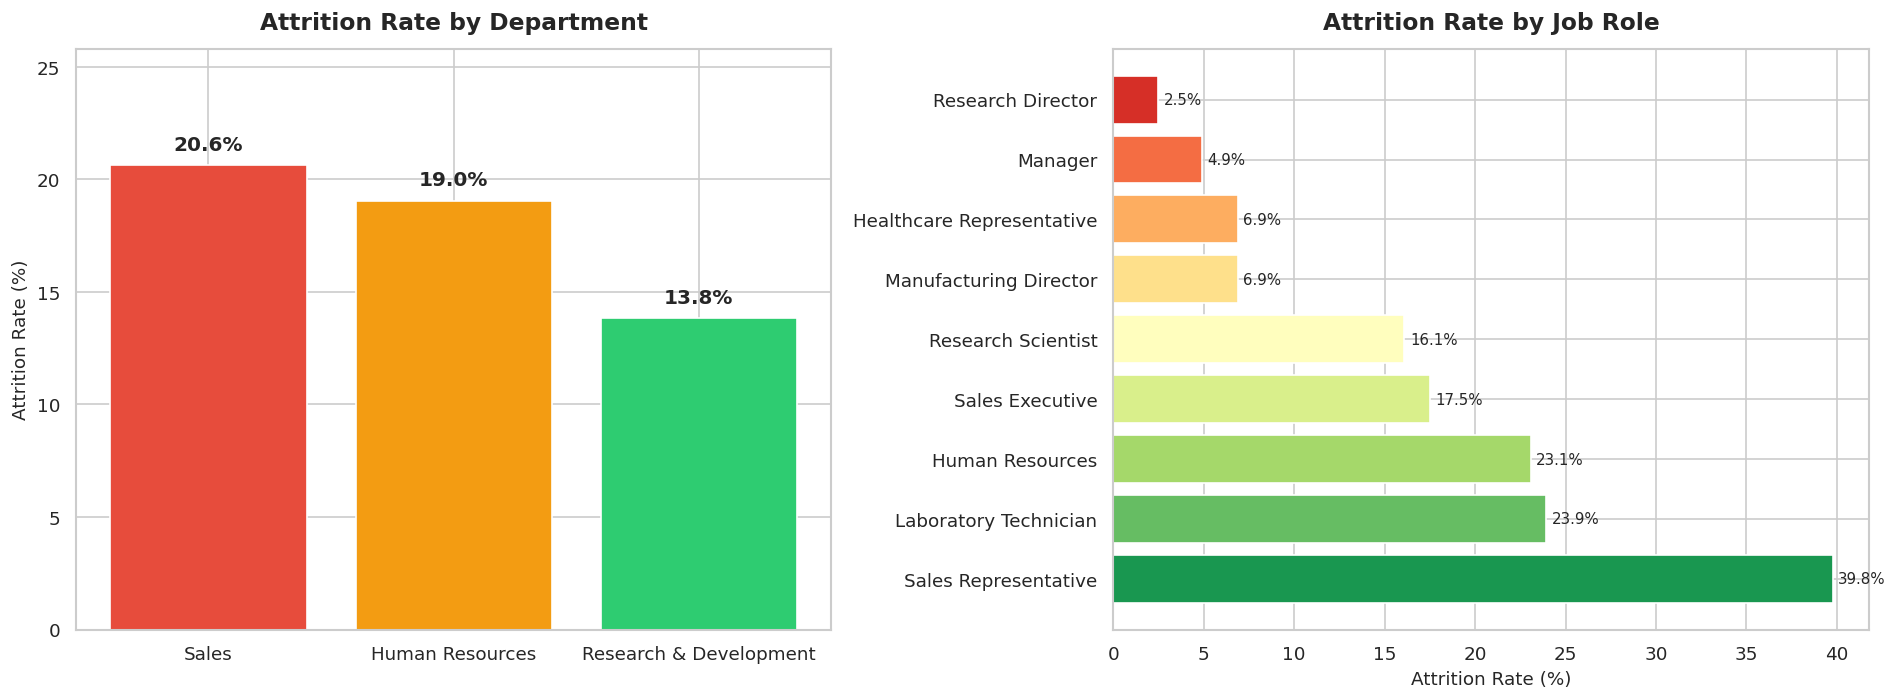

✅ Chart 1 saved.


In [30]:
import os
os.makedirs('charts', exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# Chart 1 — Attrition Rate by Department & Job Role
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Department
dept_data = (df_eda.groupby('Department')['AttritionNum']
                    .mean().mul(100).sort_values(ascending=False))
bars = axes[0].bar(dept_data.index, dept_data.values,
                   color=['#E74C3C','#F39C12','#2ECC71'])
axes[0].set_title('Attrition Rate by Department', fontsize=14, fontweight='bold', pad=12)
axes[0].set_ylabel('Attrition Rate (%)', fontsize=11)
axes[0].set_ylim(0, dept_data.max() * 1.25)
for bar, val in zip(bars, dept_data.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Job Role
role_data = (df_eda.groupby('JobRole')['AttritionNum']
                    .mean().mul(100).sort_values(ascending=False))
colors = sns.color_palette('RdYlGn_r', len(role_data))
axes[1].barh(role_data.index, role_data.values, color=colors)
axes[1].set_title('Attrition Rate by Job Role', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Attrition Rate (%)', fontsize=11)
for i, (val, name) in enumerate(zip(role_data.values, role_data.index)):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('charts/chart1_attrition_by_dept_role.png', bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved.")


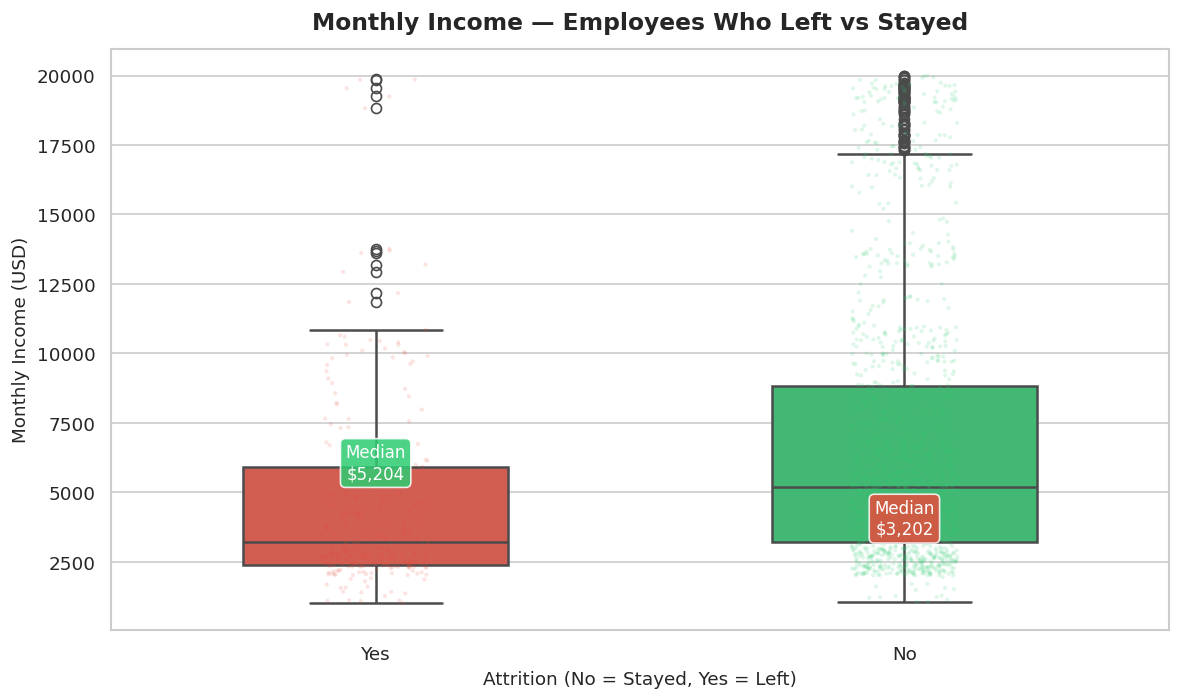

✅ Chart 2 saved.


In [31]:
# ══════════════════════════════════════════════════════════════════════════════
# Chart 2 — Monthly Income: Left vs Stayed (Box Plot)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))

palette = {'No': '#2ECC71', 'Yes': '#E74C3C'}
sns.boxplot(data=df_eda, x='Attrition', y='MonthlyIncome',
            palette=palette, width=0.5, linewidth=1.5, ax=ax)
sns.stripplot(data=df_eda, x='Attrition', y='MonthlyIncome',
              palette=palette, alpha=0.15, jitter=True, size=2.5, ax=ax)

ax.set_title('Monthly Income — Employees Who Left vs Stayed',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Attrition (No = Stayed, Yes = Left)', fontsize=11)
ax.set_ylabel('Monthly Income (USD)', fontsize=11)

# Annotate medians
for i, group in enumerate(['No', 'Yes']):
    median = df_eda[df_eda['Attrition'] == group]['MonthlyIncome'].median()
    ax.text(i, median + 150, f'Median\n${median:,.0f}',
            ha='center', va='bottom', fontsize=10,
            color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=palette[group], alpha=0.85))

plt.tight_layout()
plt.savefig('charts/chart2_income_boxplot.png', bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved.")


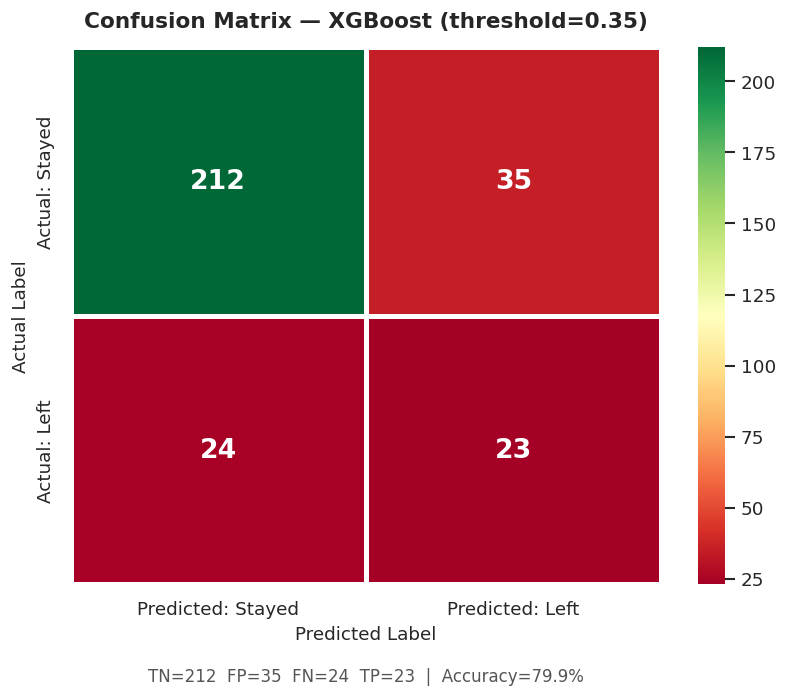

✅ Chart 3 saved.


In [32]:
# ══════════════════════════════════════════════════════════════════════════════
# Chart 3 — Confusion Matrix Heatmap (Best Model: XGBoost, tuned threshold)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 6))

cm = confusion_matrix(y_test, xgb_pred_tuned)

sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Predicted: Stayed','Predicted: Left'],
            yticklabels=['Actual: Stayed','Actual: Left'],
            linewidths=2, linecolor='white', annot_kws={'size':16,'weight':'bold'},
            ax=ax)

ax.set_title(f'Confusion Matrix — XGBoost (threshold={best_t})',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Actual Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)

tn, fp, fn, tp = cm.ravel()
ax.text(0.5, -0.18,
        f'TN={tn}  FP={fp}  FN={fn}  TP={tp}  |  '
        f'Accuracy={((tn+tp)/cm.sum()*100):.1f}%',
        ha='center', transform=ax.transAxes, fontsize=10, color='#555')

plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrix.png', bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved.")


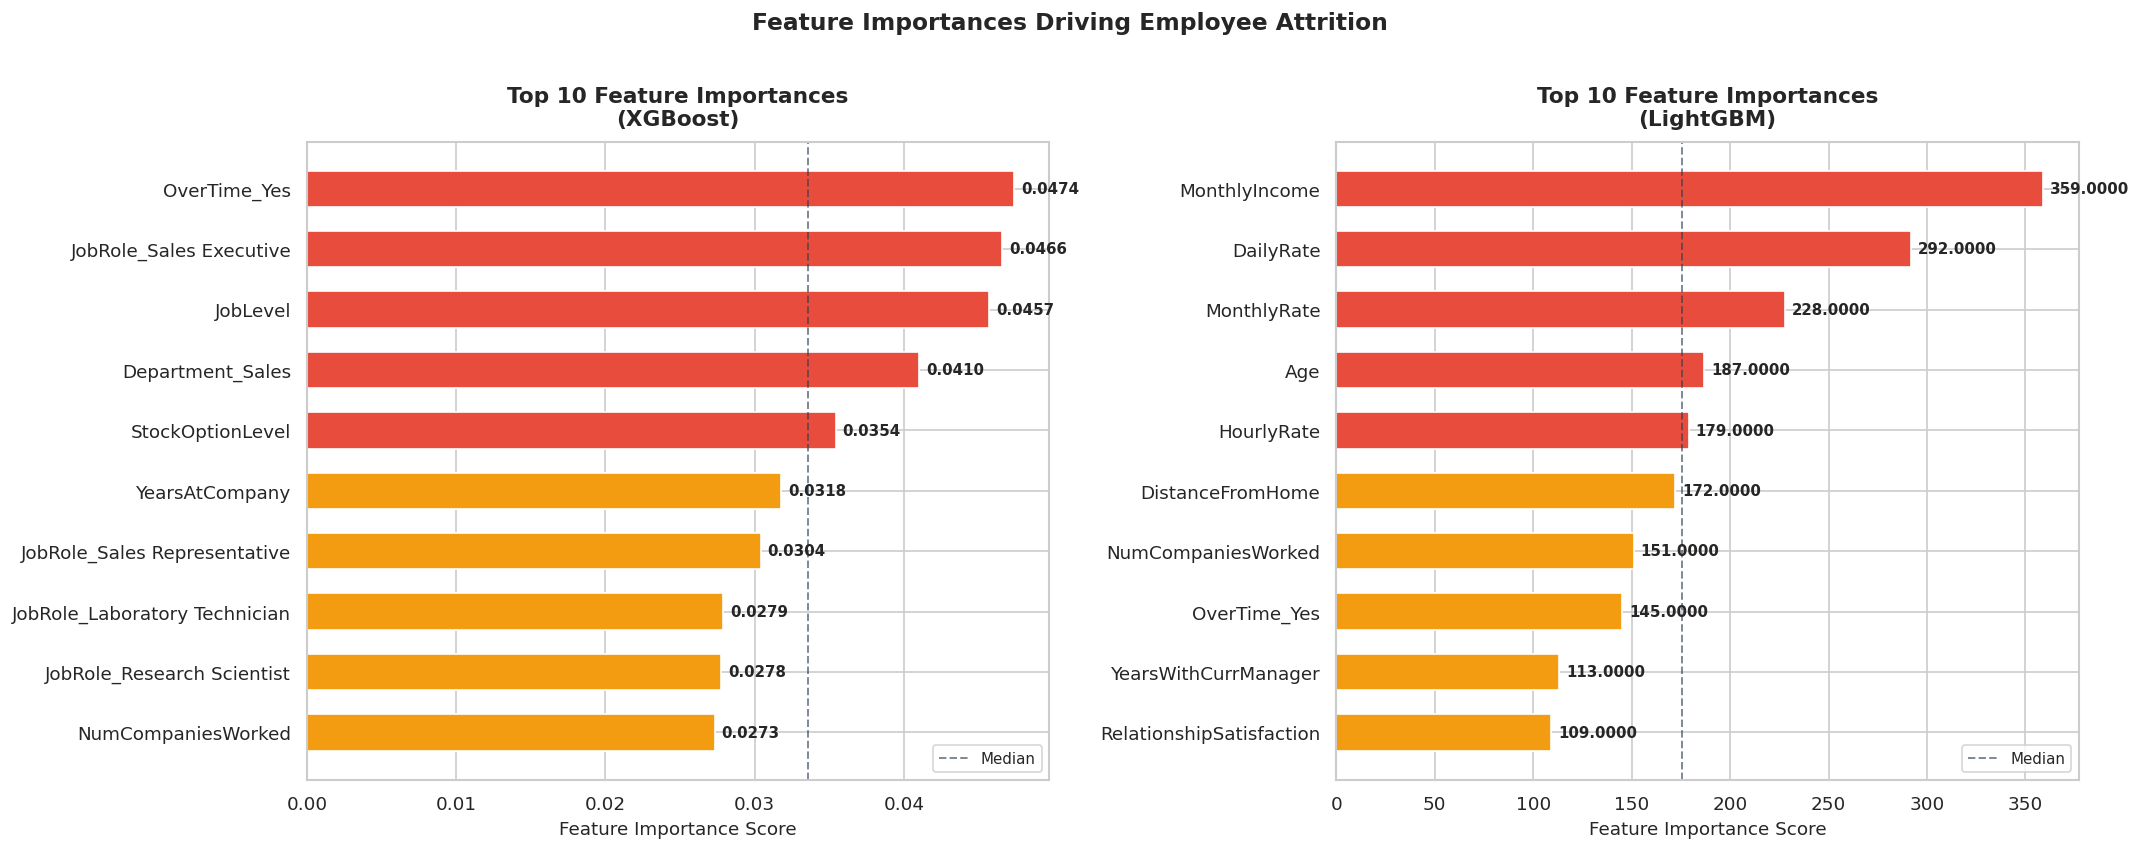

✅ Chart 4 saved.


In [33]:
# ══════════════════════════════════════════════════════════════════════════════
# Chart 4 — Top 10 Feature Importances: XGBoost vs LightGBM side-by-side
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (title, top) in zip(axes, [
    ('XGBoost',   top10),
    ('LightGBM',  top10_lgbm),
]):
    colors = ['#E74C3C' if v > top.median() else '#F39C12' for v in top.values]
    bars = ax.barh(top.index, top.values, color=colors, edgecolor='white', height=0.6)
    ax.set_title(f'Top 10 Feature Importances\n({title})',
                 fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Feature Importance Score', fontsize=11)
    ax.axvline(top.median(), color='#2C3E50', linestyle='--', linewidth=1.2,
               alpha=0.6, label='Median')
    for bar, val in zip(bars, top.values):
        ax.text(val + top.max()*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Feature Importances Driving Employee Attrition',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved.")


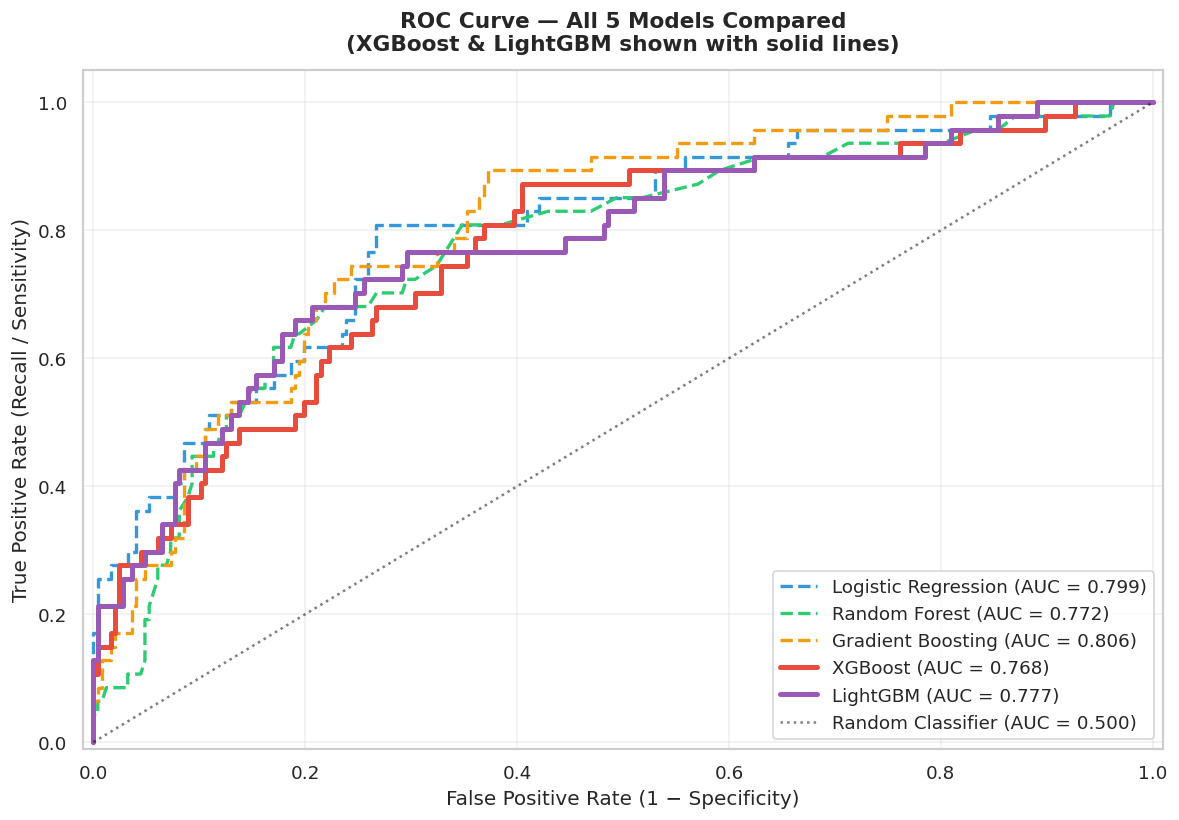

✅ Chart 5 saved.


In [34]:
# ══════════════════════════════════════════════════════════════════════════════
# Chart 5 (BONUS) — ROC Curve: All 5 Models on One Graph
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 7))

model_list = [
    ('Logistic Regression', lr_prob,   '#3498DB'),
    ('Random Forest',       rf_prob,   '#2ECC71'),
    ('Gradient Boosting',   gb_prob,   '#F39C12'),
    ('XGBoost',             xgb_prob,  '#E74C3C'),
    ('LightGBM',            lgbm_prob, '#9B59B6'),
]

for name, prob, color in model_list:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc         = roc_auc_score(y_test, prob)
    lw = 3 if name in ('XGBoost', 'LightGBM') else 2
    ls = '-' if name in ('XGBoost', 'LightGBM') else '--'
    ax.plot(fpr, tpr, lw=lw, linestyle=ls, color=color,
            label=f'{name} (AUC = {auc:.3f})')

ax.plot([0,1],[0,1], 'k:', lw=1.5, alpha=0.5, label='Random Classifier (AUC = 0.500)')
ax.fill_between([0,1],[0,1],[0,1], alpha=0.04, color='grey')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
ax.set_xlabel('False Positive Rate (1 − Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=12)
ax.set_title('ROC Curve — All 5 Models Compared\n(XGBoost & LightGBM shown with solid lines)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('charts/chart5_roc_curve_all_models.png', bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved.")


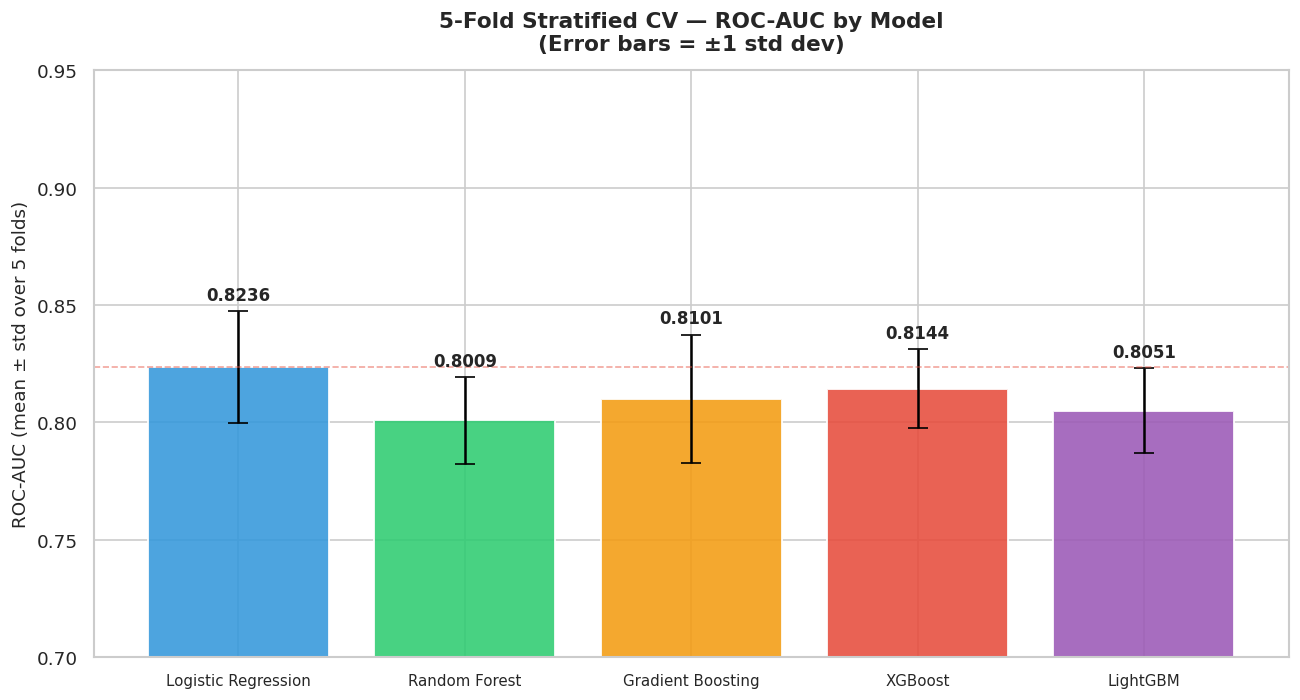

✅ Chart 6 saved.


In [35]:
# ══════════════════════════════════════════════════════════════════════════════
# Chart 6 (NEW) — 5-Fold CV ROC-AUC Comparison with Error Bars
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 6))

names  = list(cv_scores.keys())
means  = [cv_scores[n].mean() for n in names]
stds   = [cv_scores[n].std()  for n in names]
colors = ['#3498DB', '#2ECC71', '#F39C12', '#E74C3C', '#9B59B6']

bars = ax.bar(names, means, yerr=stds, color=colors, capsize=6,
              edgecolor='white', linewidth=1.2, alpha=0.88)

ax.set_ylim(0.70, 0.95)
ax.set_ylabel('ROC-AUC (mean ± std over 5 folds)', fontsize=11)
ax.set_title('5-Fold Stratified CV — ROC-AUC by Model\n(Error bars = ±1 std dev)',
             fontsize=13, fontweight='bold', pad=12)
ax.axhline(max(means), color='#E74C3C', linestyle='--', linewidth=1, alpha=0.5)

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.003,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.savefig('charts/chart6_cv_comparison.png', bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved.")


---
## Task 7 — HR Insights & Business Recommendations

In [36]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║          HR INSIGHTS & BUSINESS RECOMMENDATIONS                            ║
╚══════════════════════════════════════════════════════════════════════════════╝

── 3 STRONGEST PREDICTORS OF ATTRITION ─────────────────────────────────────

1. OverTime (Yes/No):  Employees who regularly work overtime are the SINGLE
   strongest predictor of leaving. Burnout from overwork is a top driver.

2. Monthly Income / Job Level:  Lower salary bands and junior job levels show
   dramatically higher exit rates. Financial dissatisfaction is a core driver —
   but it interacts with role, not income alone.

3. Years at Company / Years with Current Manager:  The 0–2 year window is
   the most critical. Short tenure and recent manager changes spike attrition.

── DEPARTMENT / ROLE TO PRIORITIZE ──────────────────────────────────────────

→ Sales Representatives (≈40% attrition rate) and the Sales department overall
  are the highest-risk groups. Laboratory Technicians and Human Resources
  professionals are also at elevated risk and are often overlooked.

── DOES SALARY ALONE EXPLAIN ATTRITION? ────────────────────────────────────

No. While lower salary correlates with higher attrition, OverTime, Work-Life
Balance rating, Years under the current manager, and Job Involvement score
all contribute independently. An employee earning a market salary but
burning out from overtime is just as likely to leave as an underpaid one.

── 2 CONCRETE HR RECOMMENDATIONS ───────────────────────────────────────────

✅ Recommendation 1 — Overtime Audit + Compensation Trigger:
   Flag any employee who has worked overtime for 3+ consecutive months.
   Offer either a workload review meeting, a bonus/compensation adjustment,
   or flexible scheduling. This targets the single strongest predictor.

✅ Recommendation 2 — Early Tenure Check-In Program (0–18 months):
   Implement a structured 30-60-90 day check-in system for all new hires,
   followed by quarterly satisfaction surveys through year 1.5.
   Pair new hires with a senior mentor to improve manager relationship scores.
   Focus this first on Sales Reps and Lab Technicians.

── MODEL LIMITATION ─────────────────────────────────────────────────────────

⚠️  This model was trained on historical data and reflects past patterns —
    it cannot account for future events (a recession, a new competitor, internal
    restructuring). It also cannot tell you WHY a specific employee is at risk —
    only that they share characteristics with past leavers. HR teams should use
    model predictions as a starting point for a conversation, not as a final
    verdict. Additionally, the dataset is imbalanced (~16% attrition), so even
    a well-tuned model will occasionally miss high-risk employees (false negatives).
    Never make compensation or HR decisions based on the model alone.
""")



╔══════════════════════════════════════════════════════════════════════════════╗
║          HR INSIGHTS & BUSINESS RECOMMENDATIONS                            ║
╚══════════════════════════════════════════════════════════════════════════════╝

── 3 STRONGEST PREDICTORS OF ATTRITION ─────────────────────────────────────

1. OverTime (Yes/No):  Employees who regularly work overtime are the SINGLE
   strongest predictor of leaving. Burnout from overwork is a top driver.

2. Monthly Income / Job Level:  Lower salary bands and junior job levels show
   dramatically higher exit rates. Financial dissatisfaction is a core driver —
   but it interacts with role, not income alone.

3. Years at Company / Years with Current Manager:  The 0–2 year window is
   the most critical. Short tenure and recent manager changes spike attrition.

── DEPARTMENT / ROLE TO PRIORITIZE ──────────────────────────────────────────

→ Sales Representatives (≈40% attrition rate) and the Sales department overall
  are th

In [34]:
print("\n╔══════ FINAL MODEL COMPARISON ══════╗")
print("  5 models ranked by ROC-AUC on test set")
print()
styled = results_df.sort_values('ROC-AUC', ascending=False).style.highlight_max(
    color='lightgreen', axis=0).highlight_min(color='#ffcccc', axis=0)
styled



╔══════ FINAL MODEL COMPARISON ══════╗
  5 models ranked by ROC-AUC on test set



,Precision,Recall,F1-Score,ROC-AUC
Model,,,,
Gradient Boosting,0.500000,0.191500,0.276900,0.805700
Logistic Regression,0.341200,0.617000,0.439400,0.798600
LightGBM,0.476200,0.425500,0.449400,0.777200
Random Forest,0.571400,0.085100,0.148100,0.771600
XGBoost,0.444400,0.340400,0.385500,0.768400


| Item | File | Status |
|------|------|--------|
| Jupyter Notebook (all 7 tasks + XGBoost/LightGBM) | `analysis.ipynb` | ✅ |
| Dataset | `WA_Fn-UseC_-HR-Employee-Attrition.csv` | ✅ |
| HR Summary (1-page, non-technical) | `summary.docx` / `summary.pdf` | ✅ |
| Chart 1 — Attrition by Dept & Role | `charts/chart1_attrition_by_dept_role.png` | ✅ |
| Chart 2 — Income Box Plot | `charts/chart2_income_boxplot.png` | ✅ |
| Chart 3 — Confusion Matrix (XGBoost, tuned threshold) | `charts/chart3_confusion_matrix.png` | ✅ |
| Chart 4 — Feature Importances XGBoost vs LightGBM | `charts/chart4_feature_importance.png` | ✅ |
| Chart 5 — ROC Curve (5 models) | `charts/chart5_roc_curve_all_models.png` | ✅ |
| Chart 6 (NEW) — 5-Fold CV Comparison | `charts/chart6_cv_comparison.png` | ✅ |


---
## Final Model Comparison Summary
